# Análisis Exploratorio de Datos (EDA)

**Detección de Grietas e Inclinación de Elementos Estructurales**
Algoritmos y Programación · Ingeniería en IA · UIS · 2026-2

---

### Cómo ejecutar este notebook

Este notebook se ejecuta **en local, con la extensión Jupyter de VS Code**. No usa Colab ni ningún servicio en la nube.

1. Abre la carpeta del proyecto en VS Code.
2. Arriba a la derecha, pulsa **Select Kernel → Python Environments → `.venv`**.
3. Ejecuta las celdas en orden (`Shift+Enter`).

Si el kernel `.venv` no aparece, créalo primero desde la terminal:

```powershell
py -3.11 -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install -r requirements.txt
```

### Qué hace este notebook (y qué no)

Este es el **único** notebook del proyecto y su alcance es exclusivamente exploratorio: mirar los datos, cuantificarlos y documentar sus sesgos. Toda la lógica que usa vive en `src/` y se importa; no se define nada aquí que después haga falta en otro sitio.

El entrenamiento, la evaluación y la exportación **no** están aquí: son scripts ejecutables por línea de comandos (`scripts/`). Un notebook no es reproducible por construcción, porque el orden de ejecución de sus celdas no queda registrado.

In [1]:
# Raíz del proyecto en sys.path para poder importar desde src/.
# Se usa pathlib y una ruta relativa al notebook: nada de rutas absolutas.
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from src.data.loader import (
    construir_inventario,
    construir_capa_aumento,
    crear_dataset,
    calcular_pesos_clase,
    detectar_estructura,
    dividir,
)
from src.utils.config import cargar_config, forma_entrada, obtener
from src.utils.rutas import asegurar_directorio, resolver
from src.utils.semillas import fijar_semillas

config = cargar_config(RAIZ / "config.yaml")
fijar_semillas(int(obtener(config, "proyecto.semilla", 42)))

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
FIGURAS = asegurar_directorio(obtener(config, "rutas.figuras", "reports/figuras"))

print(f"Raíz del proyecto : {RAIZ}")
print(f"Figuras se guardan en: {FIGURAS}")
print(f"Semilla global    : {obtener(config, 'proyecto.semilla')}")

Raíz del proyecto : c:\proyecto_algoritmos\crack-risk-assessment
Figuras se guardan en: C:\proyecto_algoritmos\crack-risk-assessment\reports\figuras
Semilla global    : 42


---
## 1. Inventario del dataset

El cargador **detecta solo** cómo está organizado el dataset: subcarpetas por clase (`Positive/`, `Negative/`) o un CSV de etiquetas. No hay que declararlo a mano.

> **Si esta celda falla**, el dataset todavía no está en su sitio. Descomprímelo dentro de `data/raw/` de forma que quede así:
>
> ```
> data/raw/Positive/00001.jpg
> data/raw/Negative/00001.jpg
> ```
>
> o bien con un `data/raw/labels.csv` que tenga las columnas indicadas en `datos.csv` de `config.yaml`.

In [2]:
directorio_datos = resolver(obtener(config, "rutas.datos_raw"))
print(f"Directorio de datos: {directorio_datos}")

estructura = detectar_estructura(directorio_datos, config)
print(f"Estructura detectada: {estructura}")

inventario = construir_inventario(directorio_datos, config)
tabla = inventario.a_dataframe()

print(f"\nTotal de imágenes: {len(inventario):,}")
print("\nConteo por clase:")
for clase, n in inventario.conteo_por_clase().items():
    print(f"  {clase:<12} {n:>7,}  ({100 * n / len(inventario):5.2f} %)")

tabla.head()

Directorio de datos: C:\proyecto_algoritmos\crack-risk-assessment\data\raw
Estructura detectada: subcarpetas

Total de imágenes: 58,138

Conteo por clase:
  Negative      34,287  (58.98 %)
  Positive      23,851  (41.02 %)


,ruta,archivo,etiqueta,clase
0,C:\proyecto_algoritmos\crack-risk-assessment\d...,00001.jpg,0,Negative
1,C:\proyecto_algoritmos\crack-risk-assessment\d...,00002.jpg,0,Negative
2,C:\proyecto_algoritmos\crack-risk-assessment\d...,00003.jpg,0,Negative
3,C:\proyecto_algoritmos\crack-risk-assessment\d...,00004.jpg,0,Negative
4,C:\proyecto_algoritmos\crack-risk-assessment\d...,00005.jpg,0,Negative


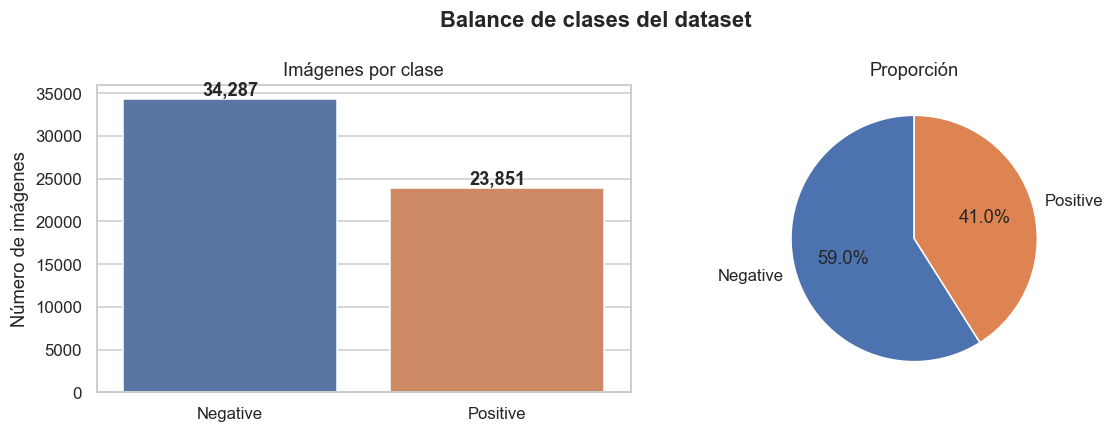

Razón minoritaria/mayoritaria: 0.696
→ Dataset razonablemente balanceado.


In [3]:
# Balance de clases. El desbalance importa mucho aquí: si la clase "con grieta"
# es minoritaria, un modelo que responda siempre "sin grieta" tendrá una
# exactitud alta y un recall nulo justo en la clase peligrosa.
conteo = inventario.conteo_por_clase()
proporcion_minoritaria = min(conteo.values()) / max(conteo.values())

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=ejes[0], hue=list(conteo.keys()), legend=False)
ejes[0].set_title("Imágenes por clase")
ejes[0].set_ylabel("Número de imágenes")
for i, v in enumerate(conteo.values()):
    ejes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

ejes[1].pie(conteo.values(), labels=conteo.keys(), autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("deep", len(conteo)))
ejes[1].set_title("Proporción")

figura.suptitle("Balance de clases del dataset", fontweight="bold")
figura.tight_layout()
figura.savefig(FIGURAS / "eda_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Razón minoritaria/mayoritaria: {proporcion_minoritaria:.3f}")
if proporcion_minoritaria < 0.5:
    print("→ Dataset DESBALANCEADO. Se activan pesos de clase (entrenamiento.pesos_clase: auto)")
    print(f"→ Pesos que se aplicarán: {calcular_pesos_clase(inventario)}")
else:
    print("→ Dataset razonablemente balanceado.")

---
## 2. Resolución, tamaño en disco y modo de color

Se muestrea un subconjunto en lugar de abrir las decenas de miles de imágenes: leer solo la cabecera de cada archivo con Pillow es rápido, pero recorrer 40 000 archivos en Windows no lo es. Con unos cientos de muestras por clase la distribución ya queda descrita.

In [4]:
N_MUESTRA = 400
generador = np.random.default_rng(int(obtener(config, "proyecto.semilla", 42)))

indices = generador.choice(len(tabla), size=min(N_MUESTRA, len(tabla)), replace=False)
registros = []

for i in indices:
    fila = tabla.iloc[int(i)]
    ruta = Path(fila["ruta"])
    try:
        with Image.open(ruta) as img:      # no decodifica los píxeles: solo la cabecera
            ancho, alto = img.size
            modo = img.mode
        registros.append({
            "clase": fila["clase"],
            "ancho": ancho,
            "alto": alto,
            "megapixeles": ancho * alto / 1e6,
            "relacion_aspecto": round(ancho / alto, 3),
            "kb": ruta.stat().st_size / 1024,
            "modo": modo,
            "formato": ruta.suffix.lower(),
        })
    except Exception as error:
        print(f"  [imagen ilegible] {ruta.name}: {error}")

muestra = pd.DataFrame(registros)
print(f"Muestra analizada: {len(muestra)} imágenes\n")
display(muestra[["ancho", "alto", "kb", "megapixeles"]].describe().round(2))

print("\nResoluciones más frecuentes:")
display(muestra.groupby(["ancho", "alto"]).size().sort_values(ascending=False).head(8).to_frame("n"))
print("\nModos de color:", muestra["modo"].value_counts().to_dict())
print("Formatos       :", muestra["formato"].value_counts().to_dict())

Muestra analizada: 400 imágenes



,ancho,alto,kb,megapixeles
count,400.00,400.00,400.00,400.00
mean,236.28,236.28,6.02,0.06
std,13.54,13.54,1.44,0.01
min,227.00,227.00,2.81,0.05
25%,227.00,227.00,5.00,0.05
50%,227.00,227.00,5.87,0.05
75%,256.00,256.00,6.92,0.07
max,256.00,256.00,10.61,0.07



Resoluciones más frecuentes:


,,n
ancho,alto,
227,227,272
256,256,128



Modos de color: {'RGB': 400}
Formatos       : {'.jpg': 400}


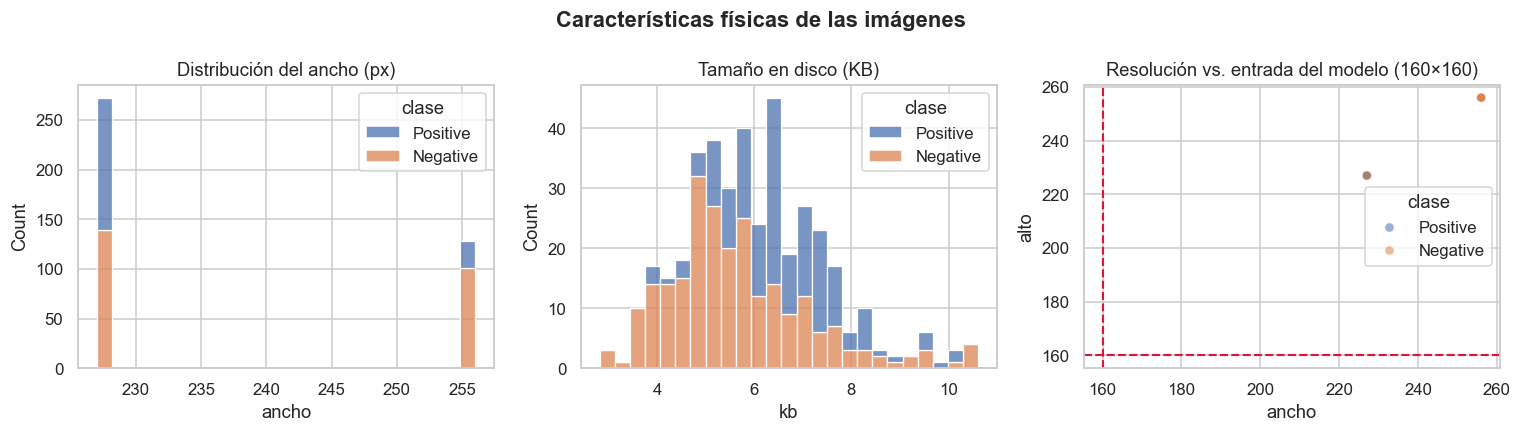

Peso medio por imagen : 6.0 KB
Peso total estimado   : 342 MB para 58,138 imágenes
Resolución de entrada : 160×160 px

Redimensionar a la entrada del modelo descarta ~2.0× píxeles.
Ese es el precio que se paga por poder entrenar en CPU; se justifica en reports/analisis.md.


In [5]:
figura, ejes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(data=muestra, x="ancho", hue="clase", multiple="stack", bins=25, ax=ejes[0])
ejes[0].set_title("Distribución del ancho (px)")

sns.histplot(data=muestra, x="kb", hue="clase", multiple="stack", bins=25, ax=ejes[1])
ejes[1].set_title("Tamaño en disco (KB)")

sns.scatterplot(data=muestra, x="ancho", y="alto", hue="clase", alpha=0.55, ax=ejes[2])
alto_modelo, ancho_modelo, _ = forma_entrada(config)
ejes[2].axvline(ancho_modelo, ls="--", c="crimson", lw=1.4)
ejes[2].axhline(alto_modelo, ls="--", c="crimson", lw=1.4)
ejes[2].set_title(f"Resolución vs. entrada del modelo ({ancho_modelo}×{alto_modelo})")

figura.suptitle("Características físicas de las imágenes", fontweight="bold")
figura.tight_layout()
figura.savefig(FIGURAS / "eda_resoluciones.png", dpi=150, bbox_inches="tight")
plt.show()

peso_total_mb = muestra["kb"].mean() * len(inventario) / 1024
print(f"Peso medio por imagen : {muestra['kb'].mean():.1f} KB")
print(f"Peso total estimado   : {peso_total_mb:,.0f} MB para {len(inventario):,} imágenes")
print(f"Resolución de entrada : {ancho_modelo}×{alto_modelo} px")

factor = (muestra['ancho'].median() * muestra['alto'].median()) / (ancho_modelo * alto_modelo)
print(f"\nRedimensionar a la entrada del modelo descarta ~{factor:.1f}× píxeles.")
print("Ese es el precio que se paga por poder entrenar en CPU; se justifica en reports/analisis.md.")

---
## 3. Rejilla de ejemplos por categoría

Mirar las imágenes es obligatorio antes de entrenar nada. Aquí es donde se detecta si el dataset son recortes de una misma superficie, si la iluminación es artificial y uniforme, o si las "grietas" son en realidad manchas y juntas.

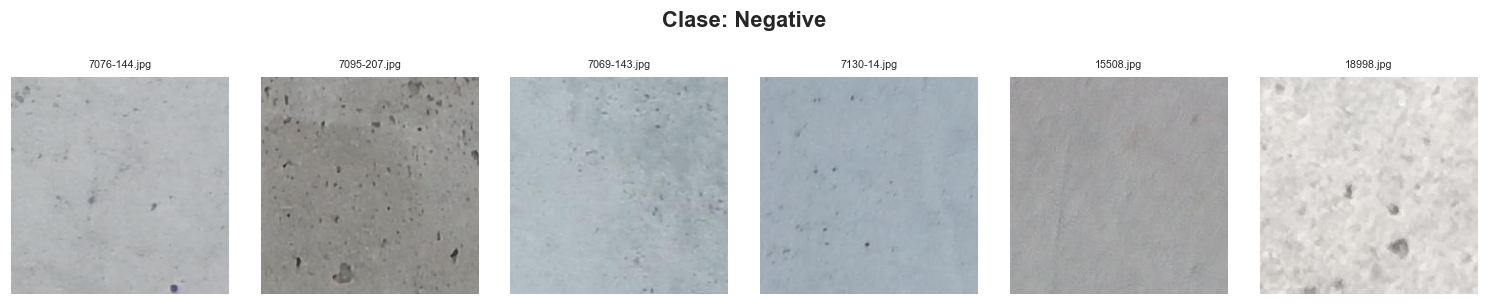

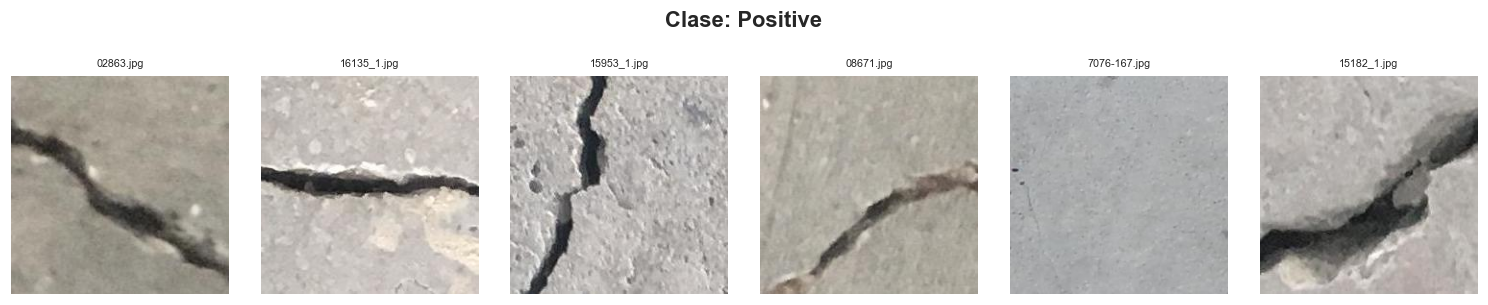

In [6]:
N_COLUMNAS = 6

for clase in inventario.clases:
    subconjunto = tabla[tabla["clase"] == clase]
    if subconjunto.empty:
        continue
    elegidas = subconjunto.sample(min(N_COLUMNAS, len(subconjunto)), random_state=42)

    figura, ejes = plt.subplots(1, len(elegidas), figsize=(2.3 * len(elegidas), 2.7))
    ejes = np.atleast_1d(ejes)
    for eje, (_, fila) in zip(ejes, elegidas.iterrows()):
        with Image.open(fila["ruta"]) as img:
            eje.imshow(img)
        eje.set_title(fila["archivo"][:16], fontsize=7)
        eje.axis("off")
    figura.suptitle(f"Clase: {clase}", fontweight="bold", y=1.02)
    figura.tight_layout()
    figura.savefig(FIGURAS / f"eda_ejemplos_{clase.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 4. La imagen como tensor: forma y rango

Antes de entrenar hay que tener claro qué le llega exactamente al modelo.

Un lote es un tensor de **cuatro dimensiones**:

$$\text{(N, H, W, C)}$$

| Símbolo | Significado | Valor en este proyecto |
|---|---|---|
| `N` | Tamaño del lote (*batch*) | `entrenamiento.batch_size` |
| `H` | Alto en píxeles | `preproceso.alto` |
| `W` | Ancho en píxeles | `preproceso.ancho` |
| `C` | Canales de color | 3 (RGB) |

**Rango de normalización.** El pipeline entrega siempre `float32` en **[0, 1]** (división por 255). MobileNetV2, en cambio, fue preentrenada con entradas en **[-1, 1]**. Esa conversión (`y = 2x − 1`) se hace **dentro del modelo**, como primera capa (`Rescaling(2.0, offset=-1.0)`).

¿Por qué así y no normalizando fuera? Porque un modelo que encapsula su propio preprocesado es un modelo que no se puede usar mal: la aplicación Streamlit y el intérprete de TFLite reciben `[0, 1]` y no necesitan saber con qué arquitectura hablan. La desincronización entre el preprocesado de entrenamiento y el de inferencia es uno de los fallos silenciosos más comunes en visión: no lanza ningún error, solo degrada el modelo.

In [7]:
lote_prueba = crear_dataset(inventario, config, entrenamiento=False, batch_size=8)
imagenes, etiquetas = next(iter(lote_prueba))

print("Tensor de imágenes")
print(f"  forma  (N, H, W, C) : {tuple(imagenes.shape)}")
print(f"  dtype               : {imagenes.dtype}")
print(f"  rango               : [{float(imagenes.numpy().min()):.4f}, {float(imagenes.numpy().max()):.4f}]")
print(f"  media / desv. est.  : {float(imagenes.numpy().mean()):.4f} / {float(imagenes.numpy().std()):.4f}")

print("\nTensor de etiquetas")
print(f"  forma               : {tuple(etiquetas.shape)}")
print(f"  dtype               : {etiquetas.dtype}")
print(f"  valores             : {etiquetas.numpy().astype(int).tolist()}")

n, h, w, c = imagenes.shape
print(f"\nMemoria de un lote: {n} × {h} × {w} × {c} × 4 bytes = "
      f"{n * h * w * c * 4 / 1024**2:.2f} MB en float32")

Tensor de imágenes
  forma  (N, H, W, C) : (8, 160, 160, 3)
  dtype               : <dtype: 'float32'>
  rango               : [0.2759, 1.0000]
  media / desv. est.  : 0.6991 / 0.0745

Tensor de etiquetas
  forma               : (8,)
  dtype               : <dtype: 'float32'>
  valores             : [0, 0, 0, 0, 0, 0, 0, 0]

Memoria de un lote: 8 × 160 × 160 × 3 × 4 bytes = 2.34 MB en float32


---
## 5. Partición estratificada y riesgo de fuga de datos

Se divide **70 / 15 / 15** con la semilla fija de `config.yaml`, manteniendo la proporción de clases en las tres particiones.

### La advertencia que hay que tomarse en serio

Los datasets públicos de grietas (Concrete Crack Images, SDNET2018) están construidos a partir de un **número reducido de fotografías madre** que después se recortan en miles de parches de 227×227. Si el reparto se hace al azar, dos parches solapados de la misma pared pueden acabar uno en entrenamiento y otro en prueba.

El resultado es una **fuga de datos**: el modelo reconoce la textura concreta de esa pared, no el concepto de grieta. La exactitud en prueba sube a valores irreales (>99 %) y se desploma con fotografías nuevas.

La solución está implementada: `datos.split.agrupar_por_origen: true` en `config.yaml` reparte **por superficie de origen**, no por imagen. La celda siguiente estima si este dataset presenta ese patrón.

In [8]:
import re

patron = obtener(config, "datos.split.regex_origen")
nombres = [Path(r).stem for r in tabla["ruta"].head(2000)]
grupos_detectados = [(re.match(patron, n).group(1) if re.match(patron, n) else n) for n in nombres]

n_unicos = len(set(grupos_detectados))
parches_por_grupo = len(grupos_detectados) / max(n_unicos, 1)

print(f"Expresión regular de origen : {patron}")
print(f"Ejemplos de nombre          : {nombres[:5]}")
print(f"Grupos distintos en la muestra: {n_unicos} sobre {len(nombres)} archivos")
print(f"Parches por grupo (media)   : {parches_por_grupo:.2f}\n")

if parches_por_grupo > 1.5:
    print("⚠ RIESGO DE FUGA DE DATOS ALTO.")
    print("  Varios archivos comparten identificador de origen. Activa en config.yaml:")
    print("      datos.split.agrupar_por_origen: true")
else:
    print("✓ Cada archivo forma su propio grupo con esta expresión regular.")
    print("  Esto NO descarta la fuga: puede que los nombres simplemente no la codifiquen.")
    print("  Inspecciona la rejilla de la sección 3: si varias imágenes parecen recortes")
    print("  de la misma pared, ajusta 'regex_origen' al patrón real de nombres.")

Expresión regular de origen : ^([A-Za-z]+[_-]?\d+)
Ejemplos de nombre          : ['00001', '00002', '00003', '00004', '00005']
Grupos distintos en la muestra: 2000 sobre 2000 archivos
Parches por grupo (media)   : 1.00

✓ Cada archivo forma su propio grupo con esta expresión regular.
  Esto NO descarta la fuga: puede que los nombres simplemente no la codifiquen.
  Inspecciona la rejilla de la sección 3: si varias imágenes parecen recortes
  de la misma pared, ajusta 'regex_origen' al patrón real de nombres.


In [9]:
particiones = dividir(inventario, config, verboso=True)

resumen = pd.DataFrame([
    {"particion": nombre,
     "n": len(parte),
     "porcentaje": round(100 * len(parte) / len(inventario), 2),
     **parte.conteo_por_clase(),
     "prop_positiva": round(float((parte.etiquetas == 1).mean()), 4)}
    for nombre, parte in particiones.items()
])
display(resumen)

desviacion = resumen["prop_positiva"].max() - resumen["prop_positiva"].min()
print(f"\nDiferencia máxima en la proporción de positivos entre particiones: {desviacion:.4f}")
print("→ Estratificación correcta." if desviacion < 0.02 else "→ Revisar la estratificación.")

  Estructura detectada : subcarpetas
  Imagenes totales     : 58138
  train :  40696 (70.0%)   Negative=24001  Positive=16695
  val   :   8721 (15.0%)   Negative=5143  Positive=3578
  test  :   8721 (15.0%)   Negative=5143  Positive=3578
  AVISO: split aleatorio. Si el dataset son recortes de una misma
         superficie, hay FUGA DE DATOS y las metricas quedaran
         infladas. Activa 'datos.split.agrupar_por_origen: true'
         en config.yaml y ajusta 'regex_origen'.


,particion,n,porcentaje,Negative,Positive,prop_positiva
0,train,40696,70.0,24001,16695,0.4102
1,val,8721,15.0,5143,3578,0.4103
2,test,8721,15.0,5143,3578,0.4103



Diferencia máxima en la proporción de positivos entre particiones: 0.0001
→ Estratificación correcta.


---
## 6. Aumento de datos (solo en entrenamiento)

El aumento se aplica **exclusivamente** a la partición de entrenamiento. Aumentar validación o prueba falsea la evaluación: se estaría midiendo el desempeño sobre imágenes que no existen.

Transformaciones activas (definidas en `preproceso.aumento`):

| Transformación | Por qué es válida aquí |
|---|---|
| Volteo horizontal **y vertical** | Una grieta en hormigón no tiene orientación "de pie" canónica; invertirla produce una muestra físicamente plausible |
| Rotación ±36° | Cubre el ángulo con que se sostiene el teléfono al fotografiar |
| Zoom y traslación | Simula distintas distancias de captura |
| Brillo y contraste | **La más importante:** el dataset está iluminado de forma uniforme y las fotos reales no lo estarán |

Sobre `cache()`: se cachea la imagen **decodificada y redimensionada** (el trabajo caro y determinista) y el aumento se aplica **después**. Cachear después del aumento congelaría las transformaciones y las volvería inútiles a partir de la segunda época.

Capas de aumento activas:
  · RandomFlip
  · RandomRotation
  · RandomZoom
  · RandomTranslation
  · RandomContrast
  · RandomBrightness


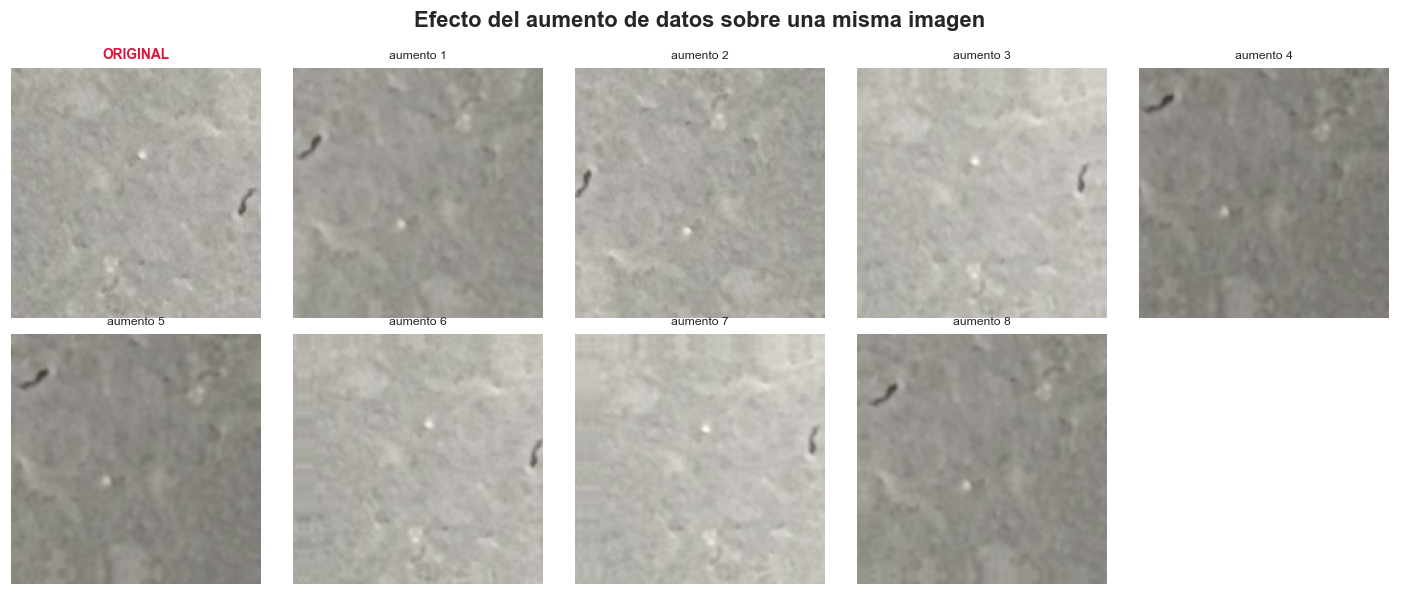

In [10]:
capa_aumento = construir_capa_aumento(config)
print("Capas de aumento activas:")
for capa in capa_aumento.layers:
    print(f"  · {capa.__class__.__name__}")

# Una misma imagen pasada ocho veces por la capa de aumento.
lote_original, _ = next(iter(crear_dataset(inventario, config, entrenamiento=False, batch_size=1)))
repetida = np.repeat(lote_original.numpy(), 8, axis=0)
aumentadas = capa_aumento(repetida, training=True).numpy()

figura, ejes = plt.subplots(2, 5, figsize=(13, 5.5))
ejes[0, 0].imshow(np.clip(lote_original.numpy()[0], 0, 1))
ejes[0, 0].set_title("ORIGINAL", fontweight="bold", fontsize=9, color="crimson")
ejes[0, 0].axis("off")

for i, eje in enumerate([e for e in ejes.ravel()][1:9]):
    eje.imshow(np.clip(aumentadas[i], 0, 1))
    eje.set_title(f"aumento {i + 1}", fontsize=8)
    eje.axis("off")
for eje in ejes.ravel()[9:]:
    eje.axis("off")

figura.suptitle("Efecto del aumento de datos sobre una misma imagen", fontweight="bold")
figura.tight_layout()
figura.savefig(FIGURAS / "eda_aumento.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Sesgos del dataset y qué implican para las fotos propias

Esta sección es análisis escrito, no código. Es también la que separa un proyecto que entrena un modelo de uno que entiende lo que entrenó.

### 7.1 Sesgos identificados

**Condiciones de iluminación.** Las imágenes del dataset están tomadas con luz uniforme y difusa, sin sombras duras ni contraluces. Las fotografías reales de una inspección se toman con la luz que haya: sol directo que satura la superficie, sombras que se parecen a fisuras, interiores mal iluminados con ruido de sensor alto.
*Implicación:* el aumento de brillo y contraste es la transformación más crítica del pipeline. Aun así no cubre las sombras proyectadas, que son geométricas y no fotométricas.

**Tipo de superficie.** Predomina el hormigón liso de laboratorio o de infraestructura reciente. Ausentes: ladrillo a la vista, pañete agrietado por retracción, superficies pintadas y descascaradas, bahareque, madera.
*Implicación:* en Colombia una fracción sustancial del parque construido es autoconstrucción con estos materiales. El modelo tenderá a producir **falsos positivos** en texturas rugosas y **falsos negativos** en superficies pintadas donde la grieta tiene bajo contraste.

**Distancia y escala de captura.** El dataset está compuesto por recortes tomados a distancia aproximadamente constante, de forma que una grieta ocupa una fracción predecible del encuadre. Una foto de una columna entera a tres metros deja la fisura reducida a unos pocos píxeles.
*Implicación:* hay que documentar una distancia de captura recomendada y advertirlo en la aplicación. Sin ese control, la generalización a fotos propias es cuestionable.

**Ausencia de negativos difíciles.** Los negativos son superficies limpias. Faltan los casos que realmente confunden: juntas de dilatación, cables, marcas de encofrado, manchas de humedad, telarañas, rayones.
*Implicación:* es el sesgo con mayor impacto práctico. El modelo puede tener un F1 excelente en prueba y disparar falsas alarmas continuamente en campo.

**Sesgo geográfico y constructivo.** Los datasets públicos provienen de infraestructura de Corea del Sur y Estados Unidos. Las prácticas constructivas, los materiales y los patrones de deterioro no son los mismos que los de una edificación colombiana.

### 7.2 Consecuencia metodológica

Todo lo anterior justifica una decisión concreta del proyecto: **`data/propias/` no participa nunca en el entrenamiento ni en la selección de hiperparámetros**. Se usa solo como conjunto de prueba final.

La **brecha** entre el F1 en `test` y el F1 en `propias` es la medida honesta de generalización, y es el número más interesante que este proyecto puede reportar. Un modelo con 0.99 en prueba y 0.62 en fotos propias no es un buen modelo: es un modelo que memorizó un dataset.

### 7.3 Protocolo de captura recomendado para el equipo

Para que `data/propias/` sea informativo y no solo anecdótico:

1. **Mínimo 30–50 imágenes**, con ambas clases representadas.
2. Distancia de **0.5 a 1.5 m** de la superficie.
3. Cámara **perpendicular** a la pared (la perspectiva sesga el ángulo de desaplome).
4. Variedad deliberada de condiciones: sol, sombra, interior, exterior.
5. Incluir a propósito **negativos difíciles**: juntas, cables, manchas, humedad.
6. Para el módulo de inclinación, algunas fotos deben mostrar **columnas o muros completos** con su borde vertical visible de arriba abajo.
7. Etiquetar en `data/propias/Positive/` y `data/propias/Negative/`.

---
## 8. Conclusiones y siguiente paso

Ejecuta la celda siguiente para obtener el resumen del EDA y los comandos exactos de la fase siguiente.

In [11]:
alto_m, ancho_m, canales_m = forma_entrada(config)

print("=" * 68)
print("  RESUMEN DEL EDA")
print("=" * 68)
print(f"  Imágenes totales      : {len(inventario):,}")
print(f"  Estructura            : {inventario.estructura}")
print(f"  Clases                : {inventario.conteo_por_clase()}")
print(f"  Balance (min/max)     : {proporcion_minoritaria:.3f}")
print(f"  Resolución de entrada : {ancho_m}×{alto_m}×{canales_m}")
print(f"  Tensor de lote        : (N, {alto_m}, {ancho_m}, {canales_m}) float32 en [0, 1]")
print(f"  Partición             : train={len(particiones['train']):,}  "
      f"val={len(particiones['val']):,}  test={len(particiones['test']):,}")
print(f"  Agrupación por origen : {obtener(config, 'datos.split.agrupar_por_origen')}")
print(f"  Figuras guardadas en  : {FIGURAS}")
print("=" * 68)
print("""
  SIGUIENTE PASO — desde la terminal de VS Code, en la raíz del proyecto:

    # 1. Ensayo rápido del pipeline completo (minutos, no horas)
    python scripts/train_baseline.py --config config.yaml --subset 0.1 --epochs 3

    # 2. Línea base completa
    python scripts/train_baseline.py --config config.yaml

    # 3. Transfer learning con MobileNetV2
    python scripts/train_transfer.py --config config.yaml
""")

  RESUMEN DEL EDA
  Imágenes totales      : 58,138
  Estructura            : subcarpetas
  Clases                : {'Negative': 34287, 'Positive': 23851}
  Balance (min/max)     : 0.696
  Resolución de entrada : 160×160×3
  Tensor de lote        : (N, 160, 160, 3) float32 en [0, 1]
  Partición             : train=40,696  val=8,721  test=8,721
  Agrupación por origen : False
  Figuras guardadas en  : C:\proyecto_algoritmos\crack-risk-assessment\reports\figuras

  SIGUIENTE PASO — desde la terminal de VS Code, en la raíz del proyecto:

    # 1. Ensayo rápido del pipeline completo (minutos, no horas)
    python scripts/train_baseline.py --config config.yaml --subset 0.1 --epochs 3

    # 2. Línea base completa
    python scripts/train_baseline.py --config config.yaml

    # 3. Transfer learning con MobileNetV2
    python scripts/train_transfer.py --config config.yaml

